# Resnet Block

In [ ]:
import torch
import torch.nn as nn
torch.backends.cudnn.benchmark = True

class SRGAN_ResBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)

# The Classic SRGAN Generator

In [ ]:
class SRGAN_Classic_Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_res_blocks=16, base_features=64):
        super().__init__()
        
        # Initial Convolution 
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, base_features, kernel_size=9, padding=4),
            nn.PReLU()
        )
        
        # 16 flat Residual Blocks
        self.res_blocks = nn.Sequential(*[SRGAN_ResBlock(base_features) for _ in range(num_res_blocks)])
        
        # Post-Residual Convolution
        self.conv_post = nn.Sequential(
            nn.Conv2d(base_features, base_features, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_features)
        )
        
        # Upsampling (32x32 -> 64x64)
        # Using the Anti-Checkerboard method (Nearest + Conv) instead of ConvTranspose
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_features, base_features, kernel_size=3, padding=1),
            nn.PReLU()
        )
        
        # Final Output Convolution
        self.final = nn.Conv2d(base_features, out_channels, kernel_size=9, padding=4)

    def forward(self, x):
        # Extract initial features
        initial_features = self.initial(x)
        
        # Pass through all 16 ResBlocks
        res_features = self.res_blocks(initial_features)
        
        # Global Skip Connection
        x = self.conv_post(res_features) + initial_features
        
        # Scale up to High-Res
        x = self.upsample(x)
        
        # Output with ReLU to strictly prevent negative physics energy
        return torch.relu(self.final(x))

# Sparse Resnet for U-Net

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # The first BatchNorm must match the incoming channels
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        # The second BatchNorm matches the internal channels
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.act = nn.SiLU()

        # Skip connection handler
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x):
        # First block
        h = self.conv1(self.act(self.bn1(x)))

        # Second block
        h = self.conv2(self.act(self.bn2(h)))

        # Skip connection
        return h + self.residual_conv(x)

# Attention Block for U-Net GAN

In [ ]:
import torchvision.models.swin_transformer as swin

# ATTENTION BLOCK (Torchvision Swin Transformer)
class AttentionBlock(nn.Module):
    """
    A drop-in wrapper for PyTorch's official Swin Transformer Block.
    Automatically handles the dimension permutations between CNNs and Transformers.
    """
    def __init__(self, channels, num_heads=4, window_size=8, shift_size=0):
        super().__init__()

        # the Torchvision Swin Block
        self.swin_block = swin.SwinTransformerBlock(
            dim=channels,
            num_heads=num_heads,
            window_size=[window_size, window_size],
            shift_size=[shift_size, shift_size],
            mlp_ratio=4.0,
            dropout=0.0,
            attention_dropout=0.0,
            stochastic_depth_prob=0.0
        )

    def forward(self, x):
        x_swin = x.permute(0, 2, 3, 1)

        # Apply the Swin Window Attention
        x_swin = self.swin_block(x_swin)

        # Convert back to (Batch, Channels, Height, Width) for the next U-Net layer
        out = x_swin.permute(0, 3, 1, 2)

        return out

# The U-Net GAN Generator

In [ ]:
class U_net_GAN_Generator(nn.Module):
    def __init__(self, image_channels=3, condition_channels=3, base_dim=64):
        super().__init__()

        # ENCODER
        # Level 1 (64x64): Upscaled LR (3) = 3 channels
        self.inc = nn.Conv2d(condition_channels, base_dim, 3, padding=1)
        
        self.res1 = ResBlock(base_dim, base_dim)

        # Level 2 (32x32): Feature Map (64) + Native LR (3) = 67 channels
        self.down1 = nn.Conv2d(base_dim, base_dim, 4, stride=2, padding=1)
        self.res2 = ResBlock(base_dim + condition_channels, base_dim * 2)

        # Level 3 (16x16): Feature Map (128) + Downsampled LR (3) = 131 channels
        self.down2 = nn.Conv2d(base_dim * 2, base_dim * 2, 4, stride=2, padding=1)
        self.res3 = ResBlock((base_dim * 2) + condition_channels, base_dim * 4)

        # BOTTLENECK (8x8)
        self.down3 = nn.Conv2d(base_dim * 4, base_dim * 4, 4, stride=2, padding=1)
        self.attn1 = AttentionBlock(base_dim * 4)
        self.res_bot = ResBlock(base_dim * 4, base_dim * 4)
        self.attn2 = AttentionBlock(base_dim * 4)

        # DECODER (With Anti-Checkerboard Upsampling)
        # Up 1 (16x16)
        self.up1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_dim * 4, base_dim * 4, 3, padding=1)
        )
        self.up_res1 = ResBlock((base_dim * 4) + (base_dim * 4), base_dim * 2)

        # Up 2 (32x32)
        self.up2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_dim * 2, base_dim * 2, 3, padding=1)
        )
        self.up_res2 = ResBlock((base_dim * 2) + (base_dim * 2), base_dim)

        # Up 3 (64x64)
        self.up3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_dim, base_dim, 3, padding=1)
        )
        self.up_res3 = ResBlock(base_dim + base_dim, base_dim)

        # Final HR Prediction
        self.final_conv = nn.Conv2d(base_dim, image_channels, 1)

    def forward(self, lr_cond):
        # Target size is 64x64
        target_size = (lr_cond.shape[2] * 2, lr_cond.shape[3] * 2)

        # ENCODER (Multi-Scale Injection)

        # Level 1 (64x64)
        lr_lvl1 = F.interpolate(lr_cond, size=target_size, mode='nearest')
        x1 = self.res1(self.inc(lr_lvl1))

        # Level 2 (32x32)
        x2 = self.down1(x1)
        lr_lvl2 = F.interpolate(lr_cond, size=x2.shape[-2:], mode='area')
        x2_injected = torch.cat([x2, lr_lvl2], dim=1)
        x2 = self.res2(x2_injected)

        # Level 3 (16x16)
        x3 = self.down2(x2)
        lr_lvl3 = F.interpolate(lr_cond, size=x3.shape[-2:], mode='area')
        x3_injected = torch.cat([x3, lr_lvl3], dim=1)
        x3 = self.res3(x3_injected)

        # Bottleneck (8x8)
        x4 = self.down3(x3)
        x4 = self.attn1(x4)
        x4 = self.res_bot(x4)
        x4 = self.attn2(x4)

        # DECODER (With Skip Connections)

        u1 = self.up1(x4)
        u1 = torch.cat([u1, x3], dim=1) # Skip connection from Level 3
        u1 = self.up_res1(u1)

        u2 = self.up2(u1)
        u2 = torch.cat([u2, x2], dim=1) # Skip connection from Level 2
        u2 = self.up_res2(u2)

        u3 = self.up3(u2)
        u3 = torch.cat([u3, x1], dim=1) # Skip connection from Level 1
        u3 = self.up_res3(u3)

        return torch.relu(self.final_conv(u3))

# Dense Block for ESRGAN

In [ ]:
import torch
import torch.nn as nn

class DenseBlock(nn.Module):
    def __init__(self, channels=64, growth_channel=32):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, growth_channel, 3, 1, 1)
        self.conv2 = nn.Conv2d(channels + growth_channel, growth_channel, 3, 1, 1)
        self.conv3 = nn.Conv2d(channels + 2 * growth_channel, growth_channel, 3, 1, 1)
        self.conv4 = nn.Conv2d(channels + 3 * growth_channel, growth_channel, 3, 1, 1)
        self.conv5 = nn.Conv2d(channels + 4 * growth_channel, channels, 3, 1, 1)
        self.lrelu = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        # Residual scaling
        return x5 * 0.2 + x

# RRDB for ESRGAN

In [ ]:
class RRDB(nn.Module):
    def __init__(self, channels=64, growth_channel=32):
        super().__init__()
        self.rdb1 = DenseBlock(channels, growth_channel)
        self.rdb2 = DenseBlock(channels, growth_channel)
        self.rdb3 = DenseBlock(channels, growth_channel)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return out * 0.2 + x

# The ESRGAN

In [ ]:
class ESRGAN_Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, num_rrdb_blocks=8, base_features=64):
        super().__init__()
        
        # Initial Convolution
        self.initial = nn.Conv2d(in_channels, base_features, kernel_size=3, padding=1)
        
        # RRDB Blocks (The feature extractor)
        self.rrdb_blocks = nn.Sequential(*[RRDB(base_features) for _ in range(num_rrdb_blocks)])
        
        # Post-RRDB Convolution
        self.conv_post = nn.Conv2d(base_features, base_features, kernel_size=3, padding=1)
        
        # Upsampling (32x32 -> 64x64, Anti-Checkerboard)
        self.upsample = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(base_features, base_features, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        # Final Output Convolution
        self.final = nn.Conv2d(base_features, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        initial_features = self.initial(x)
        
        # Pass through RRDBs
        rrdb_features = self.rrdb_blocks(initial_features)
        
        # Global skip connection
        x = self.conv_post(rrdb_features) + initial_features
        
        # Upsample to High-Res
        x = self.upsample(x)
        
        # Output with ReLU to strictly prevent negative physics energy!
        return torch.relu(self.final(x))

# The Discriminator

In [ ]:
import torch
import torch.nn as nn

class SRGAN_Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        
        self.model = nn.Sequential(
            # Input: [Batch, 3, 64, 64] -> Output: [Batch, 64, 32, 32]
            nn.Conv2d(in_channels, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output: [Batch, 128, 16, 16]
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: [Batch, 256, 8, 8]
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Output: [Batch, 512, 4, 4]
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # Condense the 4x4 grid into a single 1x1 value
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
            nn.Flatten(),       # Flattens [Batch, 1, 1, 1] -> [Batch, 1]
        )

    def forward(self, x):
        """
        Input: [B, 3, 64, 64] (Either Real HR from dataset, or Fake HR from Generator)
        Output: [B, 1] (Probability score of being Real)
        """
        return self.model(x)

# Physical Constraint Loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GANPhysicsLoss(nn.Module):
    # Added core_weight and halo_weight!
    def __init__(self, core_weight=2.0, halo_weight=15.0, energy_weight=1.0):
        super().__init__()
        self.core_weight = core_weight
        self.halo_weight = halo_weight
        self.energy_weight = energy_weight

    def forward(self, fake_hr, real_hr):
        # Base Pixel Error
        base_loss = F.l1_loss(fake_hr, real_hr, reduction='none')

        # Split the masks based on energy levels
        # Core: Bright pixels (value > 1.0)
        core_mask = (real_hr > 1.0).float()
        
        # Halo: Faint scattered pixels (value between 0.0 and 1.0)
        halo_mask = ((real_hr > 0.0) & (real_hr <= 1.0)).float()

        # Apply the multiplier to the scattering!
        weight_matrix = 1.0 + (self.core_weight * core_mask) + (self.halo_weight * halo_mask)
        weighted_image_loss = (base_loss * weight_matrix).mean()

        # Energy Conservation
        real_energy_target = torch.expm1(torch.clamp(real_hr, min=0.0, max=15.0))
        real_energy_predicted = torch.expm1(torch.clamp(fake_hr, min=0.0, max=15.0))

        total_energy_target = real_energy_target.sum(dim=(2, 3))
        total_energy_predicted = real_energy_predicted.sum(dim=(2, 3))

        log_sum_target = torch.log1p(total_energy_target)
        log_sum_predicted = torch.log1p(total_energy_predicted)

        energy_loss = F.smooth_l1_loss(log_sum_predicted, log_sum_target)

        # Total Physics Loss
        total_physics_loss = weighted_image_loss + (self.energy_weight * energy_loss)

        return total_physics_loss, weighted_image_loss, energy_loss

# Shower Profile Loss

In [11]:
def shower_profile_loss(pred_hr, real_hr):
    # Sum across the Y-axis to get the X-profile (Width spread)
    profile_x_pred = torch.sum(pred_hr, dim=2)
    profile_x_real = torch.sum(real_hr, dim=2)
    
    # Sum across the X-axis to get the Y-profile (Height spread)
    profile_y_pred = torch.sum(pred_hr, dim=3)
    profile_y_real = torch.sum(real_hr, dim=3)
    
    # Calculate how well the overall shapes match using MSE
    loss_x = nn.functional.mse_loss(profile_x_pred, profile_x_real)
    loss_y = nn.functional.mse_loss(profile_y_pred, profile_y_real)
    
    return loss_x + loss_y

# Checking the Progress

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import torch
import os

def check_progress_gan(generator, lr_sample, hr_target, epoch, it):
    generator.eval()
    
    with torch.no_grad():
        # Generate the High-Res prediction directly from the Low-Res input
        fake_hr = generator(lr_sample)

        # Setup the 4-panel plot
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
        ch = 1 # Focusing on the ECAL channel

        # PLOTTING
        def plot_panel(ax, tensor_data, title, use_lognorm=True):
            # Extract image and safely convert to numpy
            img = tensor_data[0, ch].cpu().numpy()

            if use_lognorm:
                # White background for physics (LogNorm hides 0s)
                vmax_val = np.nanmax(img)
                if np.isnan(vmax_val) or vmax_val <= 1e-4:
                    vmax_val = 1.0
                im = ax.imshow(img, cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax_val + 1e-4))
            else:
                # Standard linear scale
                im = ax.imshow(img, cmap='jet')

            ax.set_title(title)
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            ax.axis('off')

        # Input (LR Condition)
        plot_panel(axes[0], lr_sample, "Input (LR Condition)", use_lognorm=True)
        
        # Generator Output (Fake HR)
        plot_panel(axes[1], fake_hr, "Predicted SR (Fake HR)", use_lognorm=True)

        # Ground Truth (Real HR)
        plot_panel(axes[2], hr_target, "Ground Truth (Real HR)", use_lognorm=True)

        # Error Map
        error_map = torch.abs(fake_hr - hr_target)
        plot_panel(axes[3], error_map, "Absolute Error (|Fake - Real|)", use_lognorm=True)

        plt.suptitle(f"Epoch {epoch} | Iteration {it}", fontsize=16)
        plt.tight_layout()

        save_dir = "/kaggle/working/progress"
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(f"{save_dir}/progress_e{epoch}_it{it}.png")
        
        plt.show()
        plt.close()

    generator.train()

# The Training Loop

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# INITIALIZATION
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize your perfectly verified models
# Comment out the models except the one to be trained

# generator = SRGAN_Classic_Generator(in_channels=3, out_channels=3, num_res_blocks=16, base_features=64).to(device)
# generator = U_net_GAN_Generator(image_channels=3, condition_channels=3, base_dim=64).to(device)
generator = ESRGAN_Generator(in_channels=3, out_channels=3, num_rrdb_blocks=8, base_features=64).to(device)

discriminator = SRGAN_Discriminator(in_channels=3).to(device)

# Initialize the losses
adversarial_loss_fn = nn.BCEWithLogitsLoss().to(device)
physics_loss_fn = GANPhysicsLoss(core_weight=2.0, halo_weight=15.0, energy_weight=1.0).to(device)

# Initialize Optimizers (Adam is standard for GANs, usually with betas=(0.5, 0.999) for stability)
optimizer_G = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=4e-5, betas=(0.5, 0.999))

# Hyperparameter
lambda_physics = 1.0 
lambda_profile = 0.5

scaler = torch.amp.GradScaler('cuda')

# THE TRAINING LOOP
def train_srgan(generator, discriminator, dataloader, epochs, device):
    print(f"Starting High-Performance Training on {device}...")
    
    # PERFORMANCE: Initialize 16-bit GradScalers
    scaler_G = torch.amp.GradScaler('cuda')
    scaler_D = torch.amp.GradScaler('cuda')
    
    # STORAGE: Initialize the tracker for the best loss
    best_physics_loss = float('inf')
    
    # Create save directories if they don't exist
    import os
    os.makedirs("/kaggle/working/weights/generator/", exist_ok=True)
    os.makedirs("/kaggle/working/weights/discriminator/", exist_ok=True)
    
    for epoch in range(epochs):
        loop = tqdm(dataloader, leave=True)
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")

        # Tracker for the epoch's average performance
        epoch_physics_error_total = 0.0

        for batch_idx, (lr, real_hr) in enumerate(loop):
            # Move data to GPU (non_blocking=True pairs perfectly with pin_memory=True)
            lr = lr.to(device, non_blocking=True)
            real_hr = real_hr.to(device, non_blocking=True)
            batch_size = lr.size(0)

            # Create labels for Adversarial Loss
            real_labels = 0.8 + 0.2 * torch.rand((batch_size, 1), device=device)
            fake_labels = 0.0 + 0.2 * torch.rand((batch_size, 1), device=device)

            # TRAIN DISCRIMINATOR
            optimizer_D.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                # Real
                pred_real = discriminator(real_hr)
                loss_D_real = adversarial_loss_fn(pred_real, real_labels)

                # Fake
                fake_hr = generator(lr)
                pred_fake = discriminator(fake_hr.detach())
                loss_D_fake = adversarial_loss_fn(pred_fake, fake_labels)

                loss_D = (loss_D_real + loss_D_fake) / 2

            # Use Scaler for D
            scaler_D.scale(loss_D).backward()
            scaler_D.step(optimizer_D)
            scaler_D.update()

            # TRAIN GENERATOR
            optimizer_G.zero_grad(set_to_none=True)

            with torch.amp.autocast('cuda'):
                gen_hr = generator(lr)
                
                # Adversarial Loss
                pred_fake_for_G = discriminator(gen_hr)
                target_real = torch.ones((batch_size, 1), device=device)
                loss_G_adv = adversarial_loss_fn(pred_fake_for_G, target_real)

                # Physics / Content Loss
                loss_G_physics, loss_img, loss_energy = physics_loss_fn(gen_hr, real_hr)
                shower_loss = shower_profile_loss(gen_hr, real_hr)

                # Combine Losses
                lambda_physics = 1.0  
                lambda_profile = 0.5  
                loss_G = loss_G_adv + (lambda_physics * loss_G_physics) + (lambda_profile * shower_loss)

            # Use Scaler for G
            scaler_G.scale(loss_G).backward()
            
            # Must unscale before clipping to keep max_norm=1.0 accurate!
            scaler_G.unscale_(optimizer_G)
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)
            
            scaler_G.step(optimizer_G)
            scaler_G.update()

            # STORAGE: Accumulate the physical errors to find the "best" model 
            current_physics_error = loss_img.item() + loss_energy.item() + shower_loss.item()
            epoch_physics_error_total += current_physics_error

            # UPDATE PROGRESS BAR
            loop.set_postfix(
                D_loss=f"{loss_D.item():.4f}",
                G_adv=f"{loss_G_adv.item():.4f}",
                G_img=f"{loss_img.item():.4f}",
                G_eng=f"{loss_energy.item():.4f}",
                Spread=f"{shower_loss.item():.4f}"
            )

            # Plot the progress every 500 batches
            if batch_idx % 500 == 0:
                check_progress_gan(generator, lr, real_hr, epoch+1, batch_idx)
        
        # SAVE LAST AND BEST WEIGHTS
        # save the most recent epoch as "last"
        torch.save(generator.state_dict(), "/kaggle/working/weights/generator/generator_last.pth")
        torch.save(discriminator.state_dict(), "/kaggle/working/weights/discriminator/discriminator_last.pth")

        # Calculate the average physics loss for this entire epoch
        avg_epoch_loss = epoch_physics_error_total / len(dataloader)
        
        # save the best weight
        if avg_epoch_loss < best_physics_loss:
            print(f"\n New Best Physics Loss: {avg_epoch_loss:.4f} (Improved from {best_physics_loss:.4f})! Saving best weights...")
            best_physics_loss = avg_epoch_loss
            
            torch.save(generator.state_dict(), "/kaggle/working/weights/generator/generator_best.pth")
            torch.save(discriminator.state_dict(), "/kaggle/working/weights/discriminator/discriminator_best.pth")

# Streaming Calorimeter dataset

In [ ]:
import torch
from torch.utils.data import IterableDataset
import pyarrow.parquet as pq
import numpy as np
import gc
class CalorimeterParquetDataset(IterableDataset):
    def __init__(self, file_list, batch_size=16):
        super().__init__()
        self.file_list = file_list
        self.batch_size = batch_size

        # Calculate the total rows once at the start
        self.total_rows = 0
        for f in file_list:
            meta = pq.read_metadata(f)
            self.total_rows += meta.num_rows

    def __len__(self):
        # Tell the DataLoader how many BATCHES to expect
        return self.total_rows // self.batch_size

    def __iter__(self):
        for file_path in self.file_list:
            parquet_file = pq.ParquetFile(file_path)

            for batch in parquet_file.iter_batches(batch_size=self.batch_size):
                # Grab the 'element' column
                col_data = batch.column(0)

                processed_images = []
                for x in col_data.to_pylist():
                    # x is a list of 12288 values
                    arr = np.array(x, dtype=np.float32)

                    if arr.size == 12288:
                        # Reshape to [Channels, H, W] -> [3, 64, 64]
                        img = arr.reshape(3, 64, 64)
                        processed_images.append(img)

                if not processed_images:
                    continue

                # HR is the 64x64 image from the file
                hr_tensor = torch.from_numpy(np.stack(processed_images)) # [B, 3, 64, 64]

                # LR is a 32x32 downsampled version we create as the 'input'
                lr_tensor = torch.nn.functional.interpolate(
                    hr_tensor, size=(32, 32), mode='area'
                )

                yield lr_tensor, hr_tensor

                del processed_images, hr_tensor, lr_tensor
                gc.collect()

def get_dataloader(file_list, batch_size=16):
    dataset = CalorimeterParquetDataset(file_list, batch_size=batch_size)
    
    # batch_size=None because your IterableDataset yields fully formed batches
    return torch.utils.data.DataLoader(
        dataset, 
        batch_size=None,
        num_workers=1,
        pin_memory=True,
        prefetch_factor=2
    )

In [15]:
import os

# Create the weights folder
save_dir = "/kaggle/working/weights/generator"
os.makedirs(save_dir, exist_ok=True)
save_dir = "/kaggle/working/weights/discriminator"
os.makedirs(save_dir, exist_ok=True)
save_dir = "/kaggle/working/progress"
os.makedirs(save_dir, exist_ok=True)

print(f"Directory ready at: {save_dir}")

Directory ready at: /kaggle/working/progress


# The Training

In [ ]:
import glob
import torch
import os

# OPTIMIZATION 1: cuDNN Benchmarking
torch.backends.cudnn.benchmark = True

# DEFINE YOUR DATA FILES
data_dir = '/kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet' 
parquet_files = glob.glob(data_dir)

print(f"Found {len(parquet_files)} Parquet files for training.")

# INITIALIZE THE DATALOADER
batch_size = 16
train_loader = get_dataloader(parquet_files, batch_size=batch_size)

# SET THE DEVICE AND LAUNCH TRAINING
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 0

print(f"Launching High-Performance GAN Training on {device} for {num_epochs} epochs...")

# Call the training loop
train_srgan(
    generator=generator, 
    discriminator=discriminator, 
    dataloader=train_loader, 
    epochs=num_epochs, 
    device=device
)

Found 1 Parquet files for training.
Launching High-Performance GAN Training on cuda for 0 epochs...
Starting High-Performance Training on cuda...


# Weight Loader

In [ ]:
import torch
import os

def load_generator_weights(model_class, weights_path, device='cuda'):
    """
    Initializes the model architecture and loads the saved weights.
    
    model_class: The uninitialized model class (e.g., SRGAN_Generator)
    weights_path: Path to the .pth file
    """
    print(f"Initializing architecture...")
    
    # Initialize the blank architecture
    model = model_class().to(device)
    
    # Check if the file exists to prevent Kaggle crashes
    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"[-] Could not find weights at {weights_path}. Did the model finish training?")
        
    print(f"Loading weights from {weights_path}...")
    
    # Load the weights safely
    # map_location=device ensures it doesn't crash if you train on GPU but evaluate on CPU
    state_dict = torch.load(weights_path, map_location=device, weights_only=True)
    
    # Inject the weights into the model
    model.load_state_dict(state_dict)
    
    # Set to evaluation mode immediately
    model.eval()
    
    print("Model loaded and ready for inference")
    return model

## Loaded the weight into the model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_file = "/kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/ESRGAN_generator_best.pth" # path to weight file
data_dir = "/kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet" # path to the dataset file
parquet_files = glob.glob(data_dir)
train_loader = get_dataloader(parquet_files, batch_size=16)

# LOAD THE TRAINED MODEL
trained_generator = load_generator_weights(
    # model_class=SRGAN_Classic_Generator, 
    # model_class=U_net_GAN_Generator,
    model_class=ESRGAN_Generator,
    weights_path=weights_file, 
    device=device
)

Initializing architecture...
Loading weights from /kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/ESRGAN_generator_best.pth...
[+] Model loaded and ready for inference!


# Predict result of n random data

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import random
import os

@torch.no_grad()
def plot_random_predictions_gan(generator, dataloader, device='cuda', n=3, channel=1):
    # Setup
    generator.eval()
    generator.to(device)
    
    print(f"Fetching {n} random samples for visual evaluation...")
    
    # Grab one batch of data
    data_iter = iter(dataloader)
    try:
        lr_batch, hr_gt_batch = next(data_iter)
    except StopIteration:
        print("Dataset is empty!")
        return
        
    actual_n = min(n, lr_batch.size(0))
    
    # Pick 'actual_n' random indices from the batch
    indices = random.sample(range(lr_batch.size(0)), actual_n)
    
    lr_samples = lr_batch[indices].to(device)
    hr_gt_samples = hr_gt_batch[indices].to(device)
    
    # Generate predictions
    hr_pred_samples = generator(lr_samples)
    
    # Setup the Matplotlib grid
    fig, axes = plt.subplots(actual_n, 3, figsize=(15, 4.5 * actual_n))
    
    if actual_n == 1:
        axes = [axes]
        
    # HELPER FUNCTION FOR PHYSICS PLOTS
    def plot_panel(ax, tensor_image, title):
        # Move to CPU, convert to numpy, select the specific detector channel
        img = tensor_image[channel].cpu().numpy()
        
        # LogNorm for physics data to handle the extreme dynamic range (10^5 GeV spikes)
        vmax_val = np.nanmax(img)
        if np.isnan(vmax_val) or vmax_val <= 1e-4:
            vmax_val = 1.0
            
        im = ax.imshow(img, cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax_val + 1e-4))
        ax.set_title(title, fontsize=14, pad=10)
        
        # Add a colorbar that scales with the specific image
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Energy / Signal', rotation=270, labelpad=15)
        ax.axis('off')

    # Populate the grid
    for i in range(actual_n):
        # Column 1: The coarse 32x32 input
        plot_panel(axes[i][0], lr_samples[i], f"Sample {i+1}: LR Condition (32x32)")
        
        # Column 2: The GAN's 64x64 attempt
        plot_panel(axes[i][1], hr_pred_samples[i], f"Sample {i+1}: GAN Prediction (64x64)")
        
        # Column 3: The actual 64x64 target
        plot_panel(axes[i][2], hr_gt_samples[i], f"Sample {i+1}: Ground Truth (64x64)")
        
    plt.suptitle(f"GAN Super-Resolution Validation (Channel {channel})", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Safely save the final grid
    save_dir = "/kaggle/working/progress"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/final_prediction_grid.png"
    plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()
    plt.close()
    
    # Set back to train mode
    generator.train() 
    print(f"Grid saved successfully to {save_path}")

Fetching 4 random samples for visual evaluation...


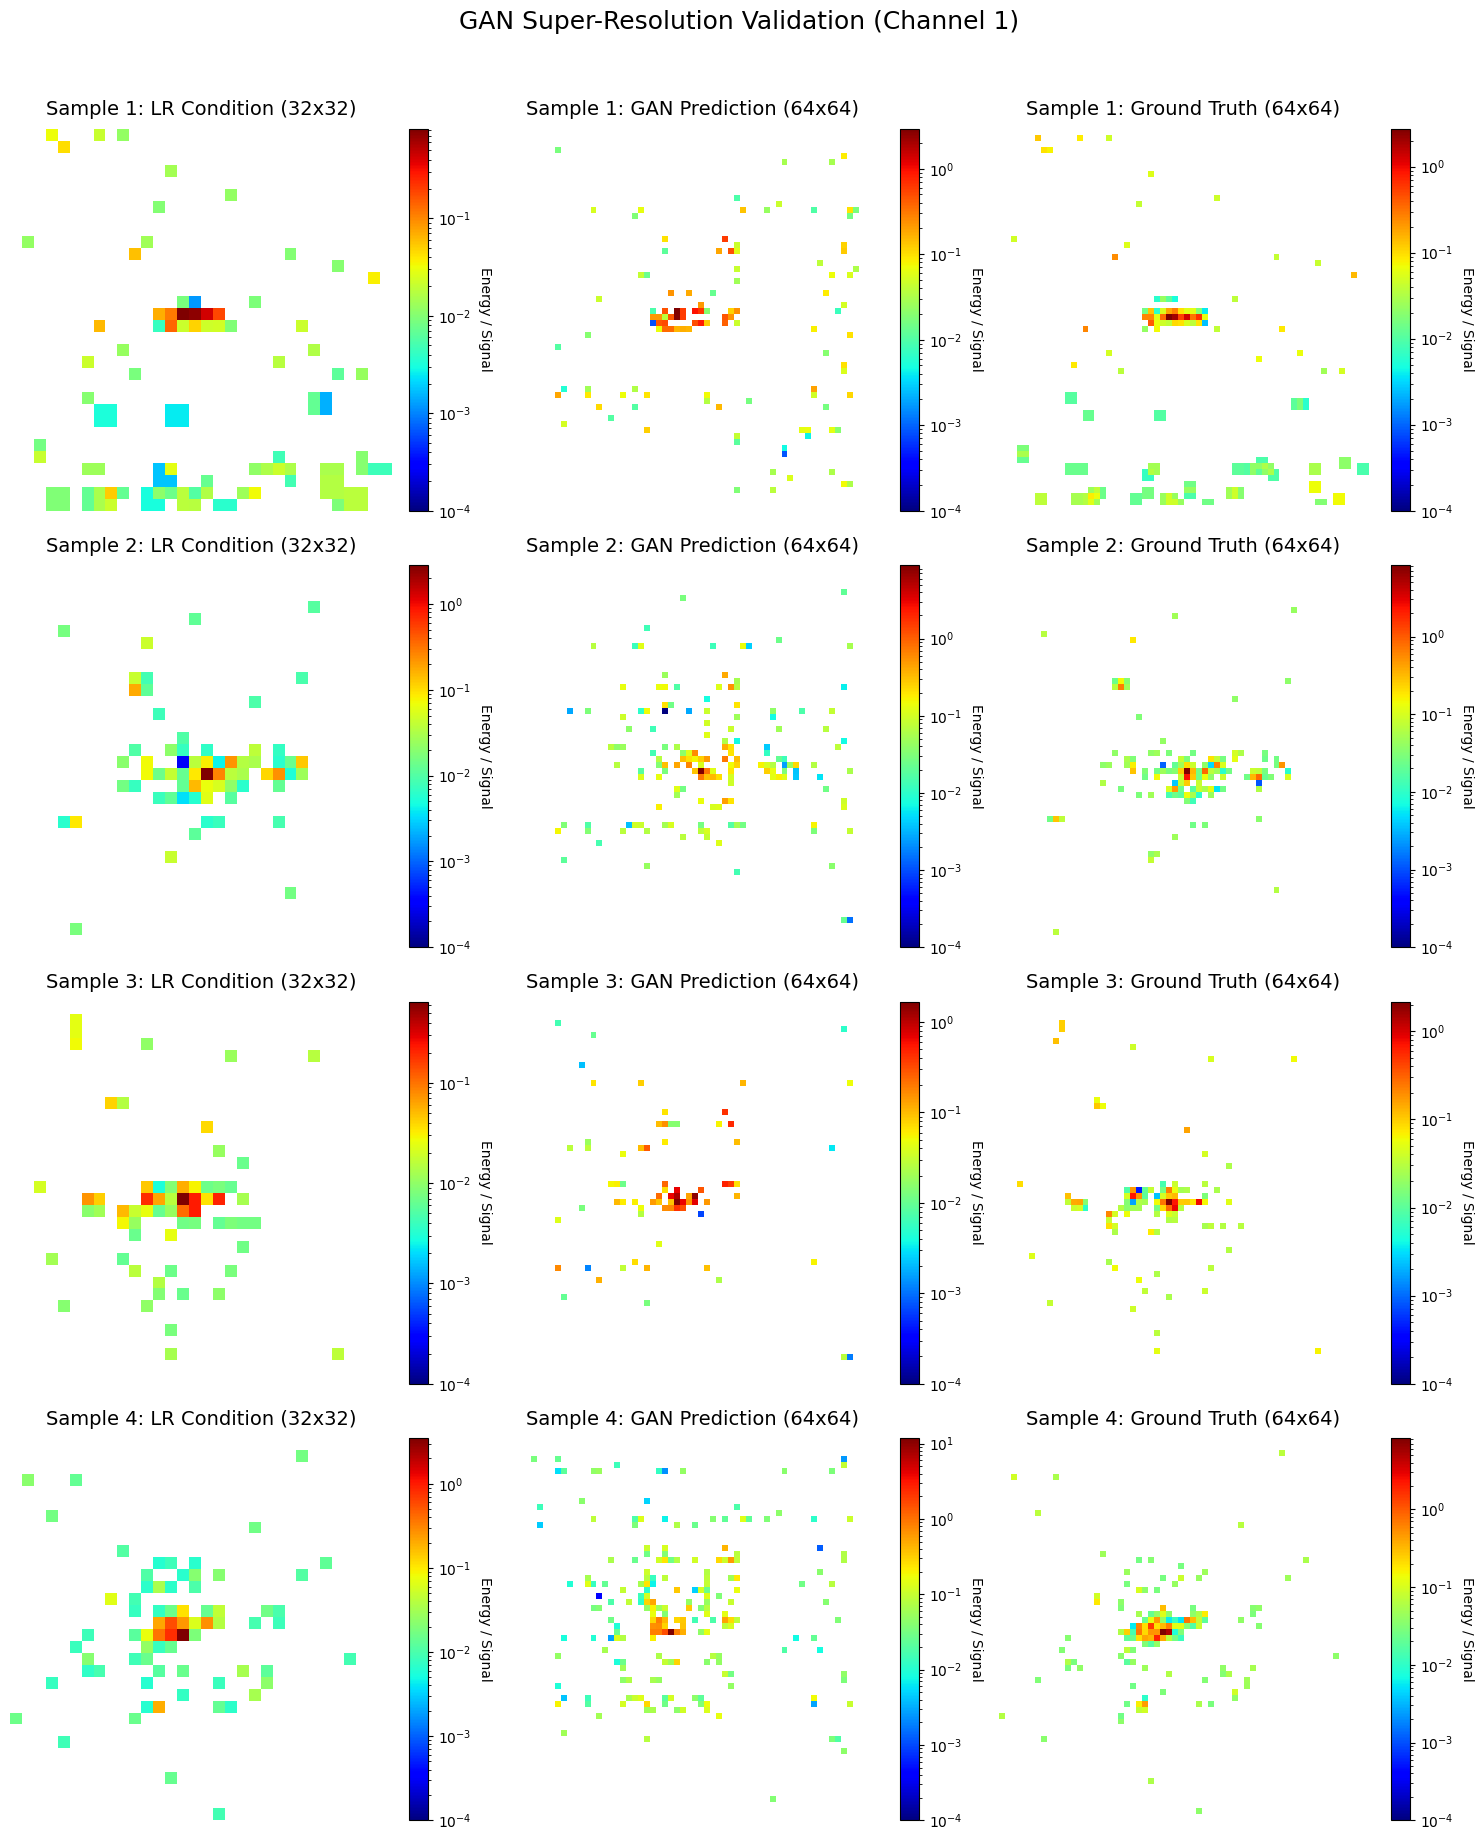

Grid saved successfully to /kaggle/working/progress/final_prediction_grid.png


In [20]:
# Plot 4 random samples, looking specifically at the ECAL channel (channel=1)
plot_random_predictions_gan(
    generator=trained_generator, 
    dataloader=train_loader, 
    device=device, 
    n=4, 
    channel=1
)

# Check Physics Constraints

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os

@torch.no_grad()
def evaluate_energy_conservation_gan(generator, dataloader, device='cuda', num_batches=5):
    generator.eval()
    generator.to(device)

    energy_ratios = []

    print(f"Evaluating Energy Conservation over {num_batches} batches...")

    # Create an iterator from dataloader
    data_iter = iter(dataloader)

    for _ in tqdm(range(num_batches), desc="Processing Samples", position=0, leave=True):
        try:
            lr_cond, hr_gt = next(data_iter)
        except StopIteration:
            break # Reached the end of the dataset

        lr_cond = lr_cond.to(device)
        hr_gt = hr_gt.to(device)

        # Generate the Super-Resolved Prediction
        hr_pred = generator(lr_cond)

        # Reverse the log transformation to get raw physics energy (GeV)
        true_energy_map = torch.expm1(torch.clamp(hr_gt, min=0.0, max=15.0))
        pred_energy_map = torch.expm1(torch.clamp(hr_pred, min=0.0, max=15.0))

        # Calculate Total Energy per sample (Sum across Channels, Height, Width)
        true_energy = true_energy_map.sum(dim=[1, 2, 3]).cpu().numpy()
        pred_energy = pred_energy_map.sum(dim=[1, 2, 3]).cpu().numpy()

        # Calculate the ratio (Prediction / Ground Truth)
        for te, pe in zip(true_energy, pred_energy):
            if te > 1e-4: # Prevent division by zero using a tiny threshold
                energy_ratios.append(pe / te)

    # PLOTTING THE HISTOGRAM
    plt.figure(figsize=(10, 6))

    # Create the histogram
    plt.hist(energy_ratios, bins=50, color='royalblue', alpha=0.7, edgecolor='black')

    # Add benchmark lines
    plt.axvline(1.0, color='red', linestyle='dashed', linewidth=2, label='Perfect Conservation (1.0)')

    mean_ratio = np.mean(energy_ratios)
    std_ratio = np.std(energy_ratios)
    plt.axvline(mean_ratio, color='green', linestyle='dashed', linewidth=2, label=f'Model Mean ({mean_ratio:.3f})')

    plt.title("Physics Validation: Energy Conservation Response (GAN)", fontsize=16)
    plt.xlabel("Ratio: Predicted Energy / True Energy", fontsize=14)
    plt.ylabel("Number of Samples", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', alpha=0.5)

    plt.tight_layout()
    
    # save to Kaggle working directory
    save_dir = "/kaggle/working/progress"
    os.makedirs(save_dir, exist_ok=True)
    plt.savefig(f"{save_dir}/final_energy_conservation_histogram.png")
    
    plt.show()

    print(f"\n=== FINAL PHYSICS STATS ===")
    print(f"Mean Energy Ratio: {mean_ratio:.4f} (Ideal is exactly 1.0000)")
    print(f"Standard Deviation: {std_ratio:.4f} (Lower means tighter predictions around 1.0)")

    # Return model to training mode just in case you run this mid-training
    generator.train() 
    return energy_ratios

Evaluating Energy Conservation over 10 batches...


Processing Samples:   0%|          | 0/10 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c43c199e020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


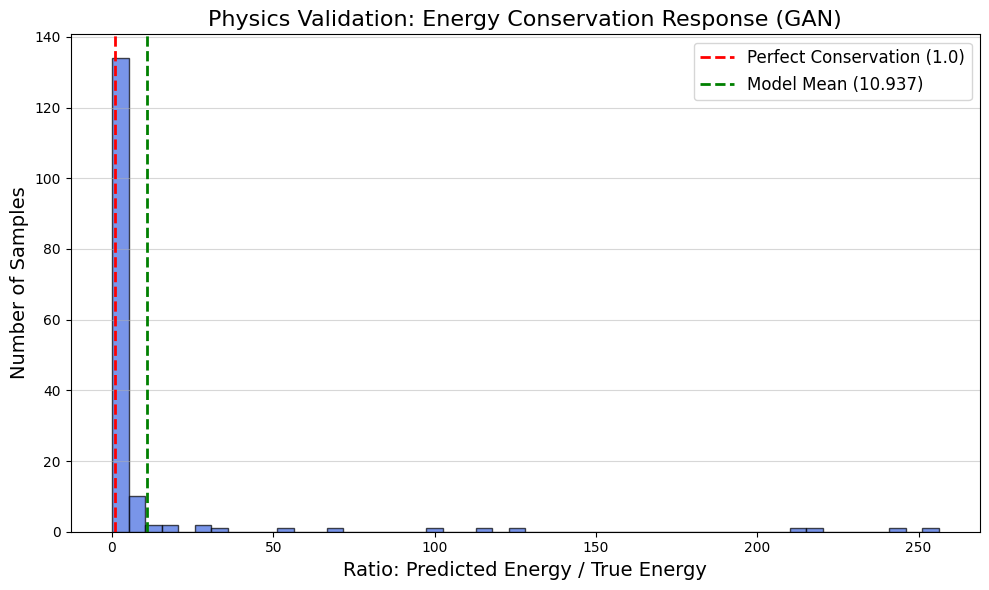


=== FINAL PHYSICS STATS ===
Mean Energy Ratio: 10.9372 (Ideal is exactly 1.0000)
Standard Deviation: 39.4774 (Lower means tighter predictions around 1.0)


In [ ]:
ratios = evaluate_energy_conservation_gan(
    generator=trained_generator, 
    dataloader=train_loader, 
    device=device, 
    num_batches=10
)

# Results of all 3 Architecture

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import random
import os

@torch.no_grad() # Prevent memory spikes during inference
def compare_all_generators(srgan, unet, esrgan, dataloader, device='cuda', n=3, channel=1):
    # Setup all models in evaluation mode
    srgan.eval().to(device)
    unet.eval().to(device)
    esrgan.eval().to(device)
    
    print(f"Fetching {n} random samples for head-to-head comparison...")
    
    # Grab one batch of data
    data_iter = iter(dataloader)
    try:
        lr_batch, hr_gt_batch = next(data_iter)
    except StopIteration:
        print("Dataset is empty!")
        return
        
    # Ensure we don't request more samples than available in the batch
    actual_n = min(n, lr_batch.size(0))
    
    # Pick random indices
    indices = random.sample(range(lr_batch.size(0)), actual_n)
    
    lr_samples = lr_batch[indices].to(device)
    hr_gt_samples = hr_gt_batch[indices].to(device)
    
    # Generate predictions for all three models simultaneously
    srgan_preds = srgan(lr_samples)
    unet_preds = unet(lr_samples)
    esrgan_preds = esrgan(lr_samples)
    
    # Setup the Matplotlib grid (5 columns wide)
    fig, axes = plt.subplots(actual_n, 5, figsize=(26, 4.5 * actual_n))
    
    # Handle single-row dimension indexing safely
    if actual_n == 1:
        axes = [axes]
        
    # HELPER FUNCTION FOR PHYSICS PLOTS
    def plot_panel(ax, tensor_image, title):
        # Move to CPU, convert to numpy, extract specific detector channel
        img = tensor_image[channel].cpu().numpy()
        
        # LogNorm handling for extreme dynamic ranges
        vmax_val = np.nanmax(img)
        if np.isnan(vmax_val) or vmax_val <= 1e-4:
            vmax_val = 1.0
            
        im = ax.imshow(img, cmap='jet', norm=LogNorm(vmin=1e-4, vmax=vmax_val + 1e-4))
        ax.set_title(title, fontsize=14, pad=10)
        
        # Attach colorbar
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Energy / Signal', rotation=270, labelpad=15)
        ax.axis('off')

    # Populate the grid
    for i in range(actual_n):
        # Column 1: Coarse LR Input
        plot_panel(axes[i][0], lr_samples[i], f"Sample {i+1}: LR Input (32x32)")
        
        # Column 2: The absolute Ground Truth
        plot_panel(axes[i][1], hr_gt_samples[i], f"Sample {i+1}: HR Ground Truth")
        
        # Column 3: Classic SRGAN
        plot_panel(axes[i][2], srgan_preds[i], f"Sample {i+1}: Classic SRGAN")
        
        # Column 4: U-Net
        plot_panel(axes[i][3], unet_preds[i], f"Sample {i+1}: U-Net GAN")
        
        # Column 5: ESRGAN
        plot_panel(axes[i][4], esrgan_preds[i], f"Sample {i+1}: ESRGAN")
        
    plt.suptitle(f"Multi-Architecture Head-to-Head Comparison (Channel {channel})", fontsize=20, y=1.02)
    plt.tight_layout()
    
    # save the final grid
    save_dir = "/kaggle/working/progress"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/all_architectures_comparison.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    
    plt.show()
    plt.close()
    
    print(f"Comparison grid saved successfully to {save_path}")

# Comparative Energy Conservation Ratio

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm.auto import tqdm

@torch.no_grad() 
def compare_energy_conservation(srgan, unet, esrgan, dataloader, device='cuda', num_batches=None):
    # Setup
    srgan.eval().to(device)
    unet.eval().to(device)
    esrgan.eval().to(device)
    
    srgan_ratios, unet_ratios, esrgan_ratios = [], [], []
    
    print("Evaluating Energy Conservation across all architectures...")
    
    # Iterate through the dataset
    for i, (lr_batch, hr_gt_batch) in enumerate(tqdm(dataloader, desc="Processing Batches")):
        if num_batches is not None and i >= num_batches:
            break
            
        lr_batch = lr_batch.to(device)
        hr_gt_batch = hr_gt_batch.to(device)
        
        # Generate Predictions
        srgan_preds = srgan(lr_batch)
        unet_preds = unet(lr_batch)
        esrgan_preds = esrgan(lr_batch)
        
        # REVERSE THE LOG TRANSFORMATION (Back to raw physical GeV)
        true_map = torch.expm1(torch.clamp(hr_gt_batch, min=0.0, max=15.0))
        srgan_map = torch.expm1(torch.clamp(srgan_preds, min=0.0, max=15.0))
        unet_map = torch.expm1(torch.clamp(unet_preds, min=0.0, max=15.0))
        esrgan_map = torch.expm1(torch.clamp(esrgan_preds, min=0.0, max=15.0))
        
        # Calculate total energy per sample
        true_energy = true_map.sum(dim=[1, 2, 3]).cpu().numpy()
        srgan_energy = srgan_map.sum(dim=[1, 2, 3]).cpu().numpy()
        unet_energy = unet_map.sum(dim=[1, 2, 3]).cpu().numpy()
        esrgan_energy = esrgan_map.sum(dim=[1, 2, 3]).cpu().numpy()
        
        # Calculate Ratios safely
        for te, sr_e, un_e, esr_e in zip(true_energy, srgan_energy, unet_energy, esrgan_energy):
            if te > 1e-4: # Prevent division by zero
                srgan_ratios.append(sr_e / te)
                unet_ratios.append(un_e / te)
                esrgan_ratios.append(esr_e / te)
        
    # PLOTTING
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    def plot_histogram(ax, ratios, title, color):
        ratios = np.array(ratios)
        mean_val = np.mean(ratios)
        std_val = np.std(ratios)
        
        # Filter extreme GAN outliers for a cleaner visualization of the bell curve
        min_bound = max(0, mean_val - 3 * std_val)
        max_bound = mean_val + 3 * std_val
        filtered_ratios = ratios[(ratios >= min_bound) & (ratios <= max_bound)]
        
        ax.hist(filtered_ratios, bins=50, color=color, edgecolor='black', alpha=0.7)
        
        # Reference Lines
        ax.axvline(1.0, color='red', linestyle='dashed', linewidth=2.5, label='Perfect (1.0)')
        ax.axvline(mean_val, color='green', linestyle='dashed', linewidth=2.5, label=f'Mean ({mean_val:.3f})')
        
        ax.set_title(f"{title}\nStd Dev: {std_val:.4f}", fontsize=16, pad=12)
        ax.set_xlabel("Ratio: Predicted Energy / True Energy", fontsize=14)
        ax.set_ylabel("Number of Samples", fontsize=14)
        ax.legend(fontsize=12)
        ax.grid(axis='y', alpha=0.4)

    # Plot each architecture
    plot_histogram(axes[0], srgan_ratios, "Classic SRGAN", "royalblue")
    plot_histogram(axes[1], unet_ratios, "U-Net GAN", "mediumseagreen")
    plot_histogram(axes[2], esrgan_ratios, "ESRGAN", "coral")
    
    plt.suptitle("Physics Validation: Energy Conservation Comparison", fontsize=20, y=1.05)
    plt.tight_layout()
    
    # Save
    save_dir = "/kaggle/working/progress"
    os.makedirs(save_dir, exist_ok=True)
    save_path = f"{save_dir}/energy_conservation_comparison.png"
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    
    plt.show()
    plt.close()
    print(f"[+] Energy comparison plot saved successfully to {save_path}")

# Energy Conservation and Result Plots for all 3 Architectures

Initializing architecture...
Loading weights from /kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/SRGAN_generator_best.pth...
[+] Model loaded and ready for inference!
Initializing architecture...
Loading weights from /kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/U-Net_generator_best.pth...
[+] Model loaded and ready for inference!
Initializing architecture...
Loading weights from /kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/ESRGAN_generator_best.pth...
[+] Model loaded and ready for inference!
Fetching 3 random samples for head-to-head comparison...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c43c199e020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process


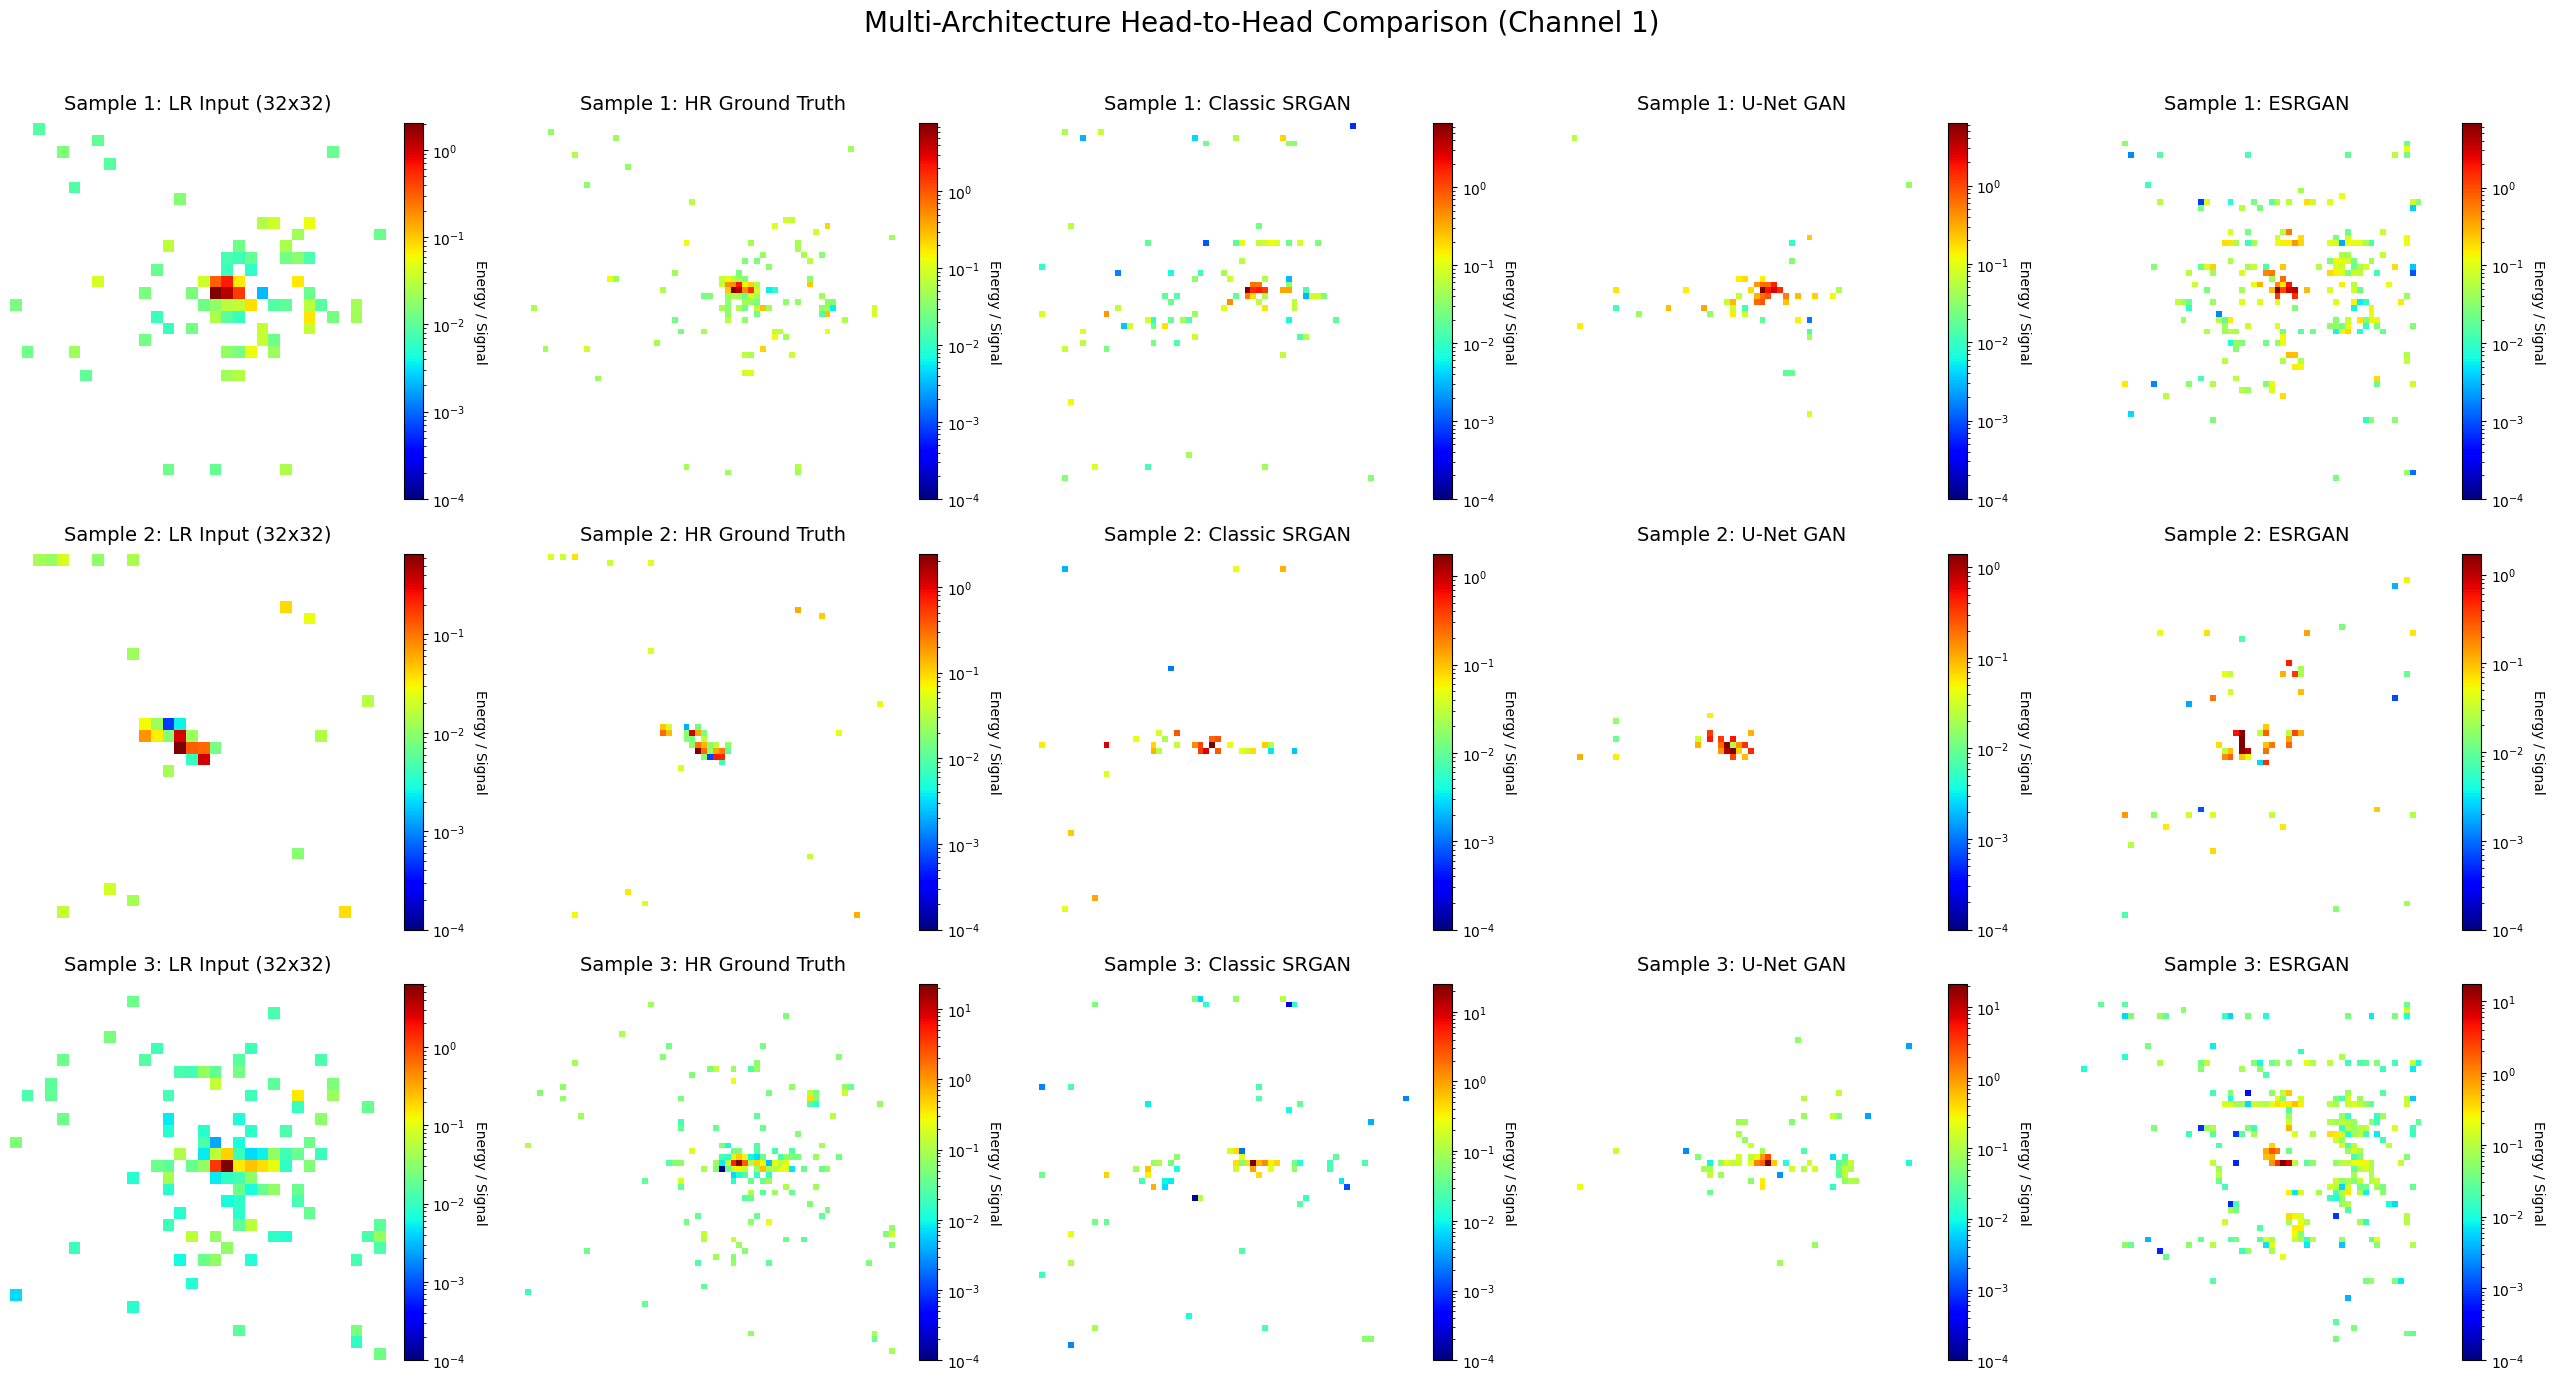

[+] Comparison grid saved successfully to /kaggle/working/progress/all_architectures_comparison.png
Evaluating Energy Conservation across all architectures...


Processing Batches:   0%|          | 0/2267 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c43c199e020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c43c199e020>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

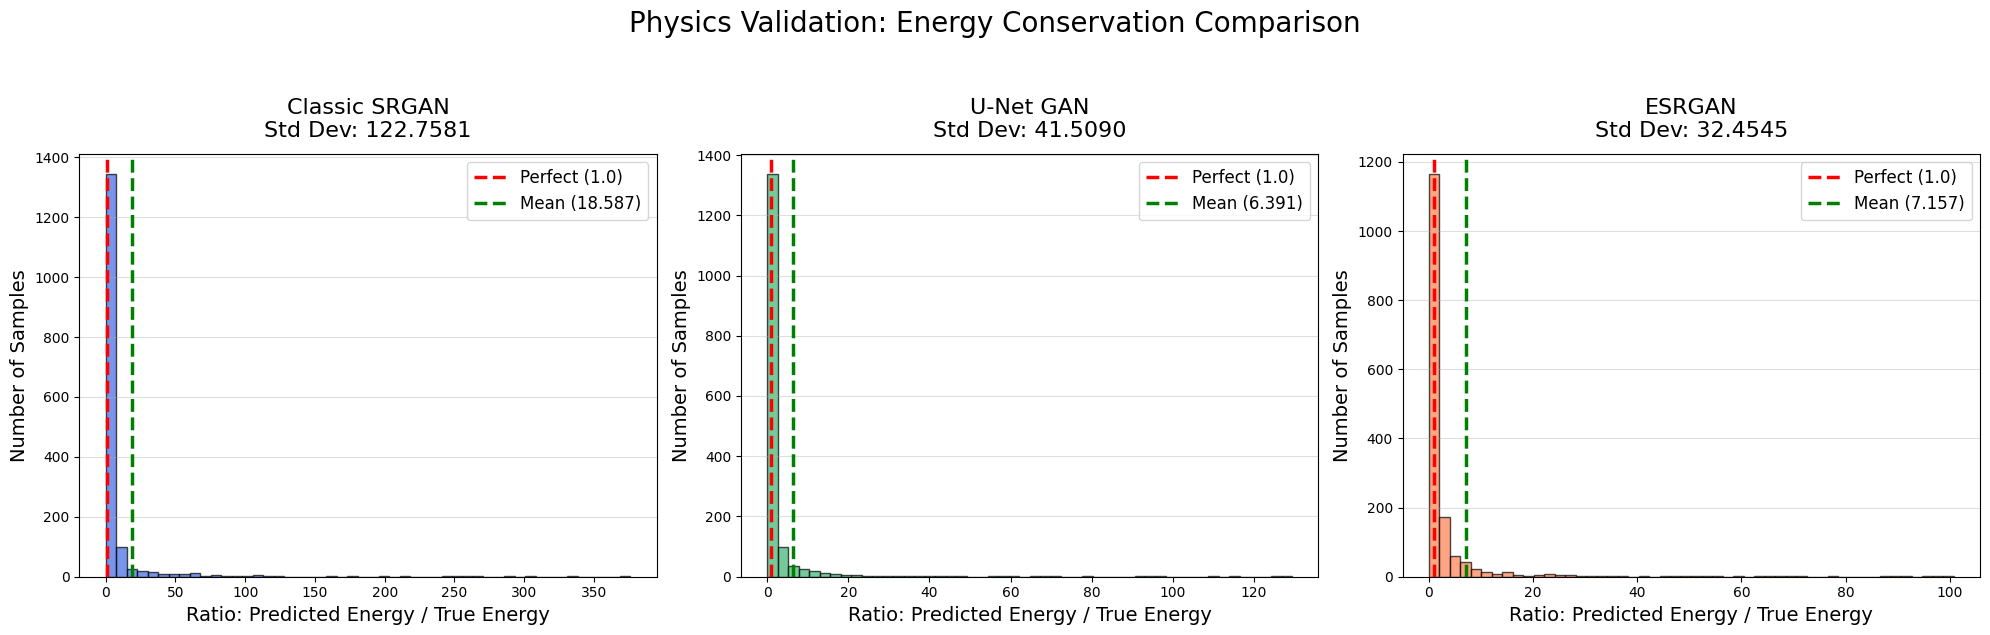

[+] Energy comparison plot saved successfully to /kaggle/working/progress/energy_conservation_comparison.png


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_dir = "/kaggle/input/datasets/bhagavatpratimdas/particle-energy/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet" # path to the dataset file
parquet_files = glob.glob(data_dir)
train_loader = get_dataloader(parquet_files, batch_size=16)

weights_SRGAN = "/kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/SRGAN_generator_best.pth"
weights_Unet = "/kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/U-Net_generator_best.pth"
weights_ESRGAN = "/kaggle/input/models/bhagavat3/gans-u-net-sr-esr/pytorch/default/1/ESRGAN_generator_best.pth"

# LOAD THE TRAINED MODEL
SRGAN_generator = load_generator_weights(
    model_class=SRGAN_Classic_Generator, 
    weights_path=weights_SRGAN, 
    device=device
)
UnetGAN_generator = load_generator_weights(
    model_class=U_net_GAN_Generator,
    weights_path=weights_Unet, 
    device=device
)
ESRGAN_generator = load_generator_weights(
    model_class=ESRGAN_Generator,
    weights_path=weights_ESRGAN, 
    device=device
)

compare_all_generators(
    srgan = SRGAN_generator,
    unet = UnetGAN_generator,
    esrgan = ESRGAN_generator,
    dataloader = train_loader,
    device='cuda',
    n=3,
    channel=1
)

compare_energy_conservation(
    srgan = SRGAN_generator,
    unet = UnetGAN_generator,
    esrgan = ESRGAN_generator,
    dataloader = train_loader,
    device='cuda',
    num_batches=100
)